---
# MLP language model with Batch Normalization 
---

In this notebook, we explore the impact on the optimization performance of the parameter initialization. We introduce the concept of Kaiming initialization to restore unit Gausian distribution of outcomes from linear layers. We then develop on the idea of batch normalization as a systematic way of assuring unit Gaussian at least at initialization.  

This notebook follows very closely the excellent [Karpathy's video lecture](https://www.youtube.com/watch?v=P6sfmUTpUmc) on the topic.

# Why parameter initialization matters? 

The main block of an MLP is of the type $x_{l+1} = f(x_l \cdot W_l + b_l)$ where $W_l$ has shape $n_l \times m_l$, $b_l$ has shape $m_l$  and $f$ is some non-linear function (typically $\tanh$ or $\mathrm{ReLU}$). The unrolled MLP architecture consists of a sequential applications of blocks of this type, followed in general by a last linear layer (yielding the logits). 

If the entries of $x_l$, $w_l$ and $b_l$ all follow unit Gaussian distributions ($0$ mean and unit standar deviation) and are independent random variables, then the entries of $y_l := x_l \cdot W_l + b_l$ have $0$ mean but standard deviation given by $\sqrt{n_l + 1}$, and therefore the dispersion of values around $0$ can be big for large values of $n_l$. This high variance, can be an issue for the non-linearity $f$ as we exemplify in the following.

## Squashing non-linear activation functions and input high variance 

By squashing non-linear activations we mean a function thap maps the entire real line to either a finite interval or a half bounded interval. More precisely: a $C^\infty$ function $f:\mathbb R \to I$ where $I$ is either a finte interval $(a, b)$ (typically: $(-1,1)$ or $(0, 1)$) or a half bounded interval of the type $(a, \infty)$ or $(-\infty, a)$. Examples of squashing functions are:

$$
\begin{align}
  & \tanh: &\mathbb R&\to& (-1, 1)\\
  &&          x&\mapsto& \frac{e^x-e^{-x}}{e^x+e^{-x}}\\
  \\
  & \sigma: &\mathbb R&\to &(0, 1)\\
  &&            x&\mapsto& \frac{1}{1+e^{-x}}
\end{align}
$$

The core of the issue lies on the boundedness of the target of these functions, which implies vanishing derivatives. Let's take the function $\tanh (x)$ as the showcase. Its derivative is 

$$\tanh'(x) = 1-\tanh^2(x)$$

which explicitly shows that for an input $x$ for which $\left|\tanh(x)\right|\sim 1$, $\tanh'(x)\sim 0$. Now soppose that for a given NN with $n$ layers we have a $\tanh$ activation acting on the outcome of layer $l$. The loss function for that NN will be of the form:

$$
 \begin{align}
    & l(\theta) = \frac{1}{B}\sum\limits_{b=1}^B f(x_b;\theta)
 \end{align}
$$

where $b$ represents the batch index and

$$
 \begin{align}
    & f(x;\theta) = f_{\theta_n}\circ\cdots \circ \tanh \circ \cdots f_{\theta_1}(x)
 \end{align}
$$

where $f_{\theta_i}$ represents the affine transformation taking place at the $i$-th layer. 

For each $j= 1, \cdots, n$, call
$$
 F_j := f_{\theta_j}\circ \cdots \circ f_{\theta_1}  
$$

where the sequence of compositions includes all the activations up to the $j$-th layer.

Let $i\leq l$. By the chain rule, the partial derivative of $f(x;\theta)$ with respect to $\theta_i$ is

$$
 \begin{align}
    & \nabla_{\theta_i} f(x;\theta) = \nabla_{x}f_{\theta_n}(F_{n-1}(x)) * \nabla_{\theta_{i}} F_{n-1}  
 \end{align}
$$

where $*$ denotes matrix product, in this case:

$$
\nabla_{x}f_{\theta_n}(F_{n-1}(x)) * \nabla_{\theta_{i}} F_{n-1} := \sum_m\left.\frac{\partial}{\partial x^m} f_{\theta_n}\right|_{F_{n-1}(x)} \nabla_{\theta_i} F_{n-1}^m
$$

We may proceed iductively up until the $l$-th layer, where we find

$$
 \begin{align}
    & \nabla_{\theta_i} f(x;\theta) = \nabla_{x}f_{\theta_n}(F_{n-1}(x)) * \cdots * \nabla_{x} f_{\theta_{l+1}}(\tanh(F_l(x))) * (1-\tanh^2(F_l(x))) \odot \nabla_{\theta_i} F_l    
 \end{align}
$$

where $\odot$ denotes component-wise multiplication. Then, if the outcome of the $l$-th layer, $F_l(x)$, is 'saturated', meaning that $\left| \tanh(F_l(x))\right|\sim 1$ then the gradient descent modification on the parameter $\theta_i$ will be vanishing or very small and in effect there will be no learning for this parameter. 

$$
  \begin{align}
    &\theta_i \leftarrow \theta_i + \lambda \,\nabla_{\theta_i} l(\theta)\\
    &\nabla_{\theta_i} l = \frac{1}{B}\sum\limits_{b=1}^B\nabla_{\theta_i} f(x;\theta) \propto 1 -\tanh^2(F_l)  
  \end{align}
$$

# Tweaking the initialization

One way to mitigate this problem is to properly initialize the weights as discussed in [Kaiming et al. 2015](https://openaccess.thecvf.com/content_iccv_2015/html/He_Delving_Deep_into_ICCV_2015_paper.html): for a matrix weight $W$ of shape $n\times m$, (the feature forward pass being $x \cdot W$) the proper initialization is 

$$
  W_0 = \sqrt{\frac{g}{n}} \,\hat W
$$

where the entries in $\hat W$ are drawn from unit Gaussian distributions. $g$ is the gain and depends on the non-linear activation. 

However, as the architecture gets more complex, finding the right weight normalization becomes increasingly difficult. 

## Normalization

A possible alternative, is "forcing" the unit variance normalization (at least at initialization). One of the first suggested approaches is the so-called Batch Normalization ([Ioffe and Szegedy, 2015](https://proceedings.mlr.press/v37/ioffe15.html)) 

Essentially, given a tensor $x$ with shape $B \times C$, the batch normalization computes the mean and standard deviation of each column in $x$ and rescales $x$ as 

$$
 x' = \frac{x - \langle x\rangle}{\sqrt{\langle (x - \langle x\rangle)^2\rangle + \epsilon}} \gamma + \beta 
$$

where $\langle\cdot\rangle$ denotes mean along the rows and $\gamma, \beta$ are learnable parameters with shape $(C, \,)$ that are initialized as $\gamma=1$ and $\beta=0$. $\epsilon\ll 1$ is introduced to avoid division by 0. Thus at least in the beginning of the training, the outcome of batch normalization is guaranteed to have zero mean and uinit standard deviation. As the optimization progresses, the gradient updates will adjust the values of $\gamma$ and $\beta$. 

# Parameter initialization

A reasonable initialization of the parameters for the model is such that the generated conditional probability $P_{\theta_0}(y \mid x)$ is roughly uniform, as we don't have any a priori reason to believe that some characters are more likely than others. Accordingly, $-\log(P_{\theta_0}(y\mid x)) \sim \log N_c$ with $N_c$ denoting the number of characters. The loss in this situation is then:

$$
l(\mathcal D; \theta_0) := -\frac{1}{M} \sum\limits_{m=1}^M \log P_{\theta_0}(y_m \mid x_m) \sim \log N_c 
$$

In our case, the initial loss should be close to $\log 27 \sim 3.3$

# Load data and extract words

Download names.txt from [this repository](https://github.com/karpathy/makemore/blob/master/names.txt)

In [1]:
import os

cwd = os.getcwd()
words = open(cwd+'/../Data/names.txt', 'r').read().split('\n')
print(f"First 10 words:\n{words[:10]}")
print(f"Total numner of words: {len(words)}")

First 10 words:
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']
Total numner of words: 32033


# Add special character to indicate end of the word

In [2]:
chars = sorted(
    list(set("".join(words))) + ['-']
)
num_chars = len(chars)

# define mappings 
i_to_c = {i: c for i, c in enumerate(chars)}
c_to_i = {c: i for i, c in i_to_c.items()} 

i_to_c

{0: '-',
 1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z'}

---
# Define the MLP architecture  
---

## Batch Norm 

## MLP class

In [152]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BatchNorm(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(hidden_dim, dtype=torch.float), requires_grad=True)
        self.beta = nn.Parameter(torch.zeros(hidden_dim, dtype=torch.float), requires_grad=True)
        self.register_buffer("running_mean", torch.zeros(1, hidden_dim, dtype=torch.float))
        self.register_buffer("running_var", torch.ones(1, hidden_dim, dtype=torch.float))
        self.out = None

    def forward(self, x, momentum=0.01, eps=1e-5):
        if self.training:
            x_mean = x.mean(dim=0, keepdim=True)
            x_var = x.var(dim=0, keepdim=True)
            y = (x - x_mean) / torch.sqrt(x_var + eps)
            # update running averages
            with torch.no_grad():
                self.running_mean = (1-momentum) * self.running_mean + momentum * x_mean
                self.running_var = (1-momentum) * self.running_var + momentum * x_var
        else: # eval mode
            y = (x - self.running_mean) / torch.sqrt(self.running_var + eps)
        self.out = y * self.gamma + self.beta
        return self.out
        

class LinearNonLinearBlock(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.ln = nn.Linear(in_dim, out_dim, bias=False)
        self.bn = BatchNorm(out_dim)
        self.out = None
        with torch.no_grad():
            # rescale the weights with the appropriate gain.
            # This operation requires no back propagation. 
            self.ln.weight *= 5/3 

    def forward(self, x):
        x = self.ln(x)
        x = self.bn(x)
        self.out = torch.tanh(x)
        return self.out

class MLP(nn.Module):
    def __init__(self, emb_dim, out_dim, block_size, num_blocks):
        super().__init__()
        self.block_size = block_size 
        self.emb_table = nn.Parameter(torch.randn(num_chars, emb_dim, dtype=torch.float), requires_grad=True)
        dims = [emb_dim*block_size] + [out_dim]*(num_blocks-1)
        self.blocks = nn.ModuleList(
            [LinearNonLinearBlock(in_dim=dim, out_dim=dims[i+1]) for i, dim in enumerate(dims[:-1])] + [nn.Linear(dims[-1], num_chars)]
        )
        with torch.no_grad():
            self.blocks[-1].weight *= 0.1 # make the last linear layer less confident at initialization 
        self.net = nn.Sequential(*self.blocks)
            

    def forward(self, x, y=None):
        """
        x has shape (batch_size, block_size). x[i, :] contains the integer tokens of the characters in the context for the i-th data point
        y has shape (batch_size, ). y[i] is the integer token of the character that follows the context for the i-th data point 
        """
        # embed tokenized-context data, concatenate along embedding dimension and apply first layer
        x = self.emb_table[x].view(x.shape[0], -1) # (batch_size, emb_dim*block_size)
        # Apply the Liner-NonLinear sequence of blocks
        logits = self.net(x)
    
        if y is None:
            loss = None
        else:
            loss = F.cross_entropy(logits, y)
        return logits, loss 

    def _num_parameters(self):
        return sum(p.nelement() for p in self.parameters())

    def _init_grad(self):
        for p in self.parameters():
            p.grad = None 
    
    def _retain_grad(self):
        for m in self.blocks[:-1]:
            m.out.retain_grad()
        

## Dummy MLP class instantiation 

In [153]:
emb_dim, out_dim, block_size, num_blocks = 10, 100, 5, 6
mlp = MLP(emb_dim=emb_dim, out_dim=out_dim, block_size=block_size, num_blocks=num_blocks)
mlp._num_parameters()

48997

### Access modules

In [154]:
shapes = {}
i=0
for m in mlp.modules():
    if type(m) is nn.Linear:
        shapes[i] = m.weight.shape
        i += 1
shapes 

{0: torch.Size([100, 50]),
 1: torch.Size([100, 100]),
 2: torch.Size([100, 100]),
 3: torch.Size([100, 100]),
 4: torch.Size([100, 100]),
 5: torch.Size([27, 100])}

### Internal modules in blocks

In [155]:
shapes = {}
i=0
for b in mlp.blocks[:-1]:
    for m in b.modules():
        if isinstance(m, nn.Linear):
            shapes[i] = m.weight.shape
            i += 1
shapes 

{0: torch.Size([100, 50]),
 1: torch.Size([100, 100]),
 2: torch.Size([100, 100]),
 3: torch.Size([100, 100]),
 4: torch.Size([100, 100])}

### Access out attribute

In [156]:
outs = {}
for i, m in enumerate(mlp.blocks[:-1]):
    outs[i] = m.out
outs

{0: None, 1: None, 2: None, 3: None, 4: None}

# Dummy training for debugging 

In [195]:
import random 

def split_data(split):
    random.shuffle(words)
    nt = int(split*len(words))
    train_words = words[:nt]
    test_words = words[nt:]
    return train_words, test_words 

def tokenize_data(words, block_size):
    X, Y = [], []
    for w in words:
        context = [0]*block_size
        for c in w+'-':
            X.append(context)
            Y.append(c_to_i[c])
            # update context
            context = context[1:] + [c_to_i[c]]
    return torch.tensor(X, dtype=torch.long), torch.tensor(Y, dtype=torch.long) 

def generate_mini_batch(Xtr, Ytr, batch_size):
    idxs = torch.randint(0, Xtr.shape[0], (batch_size, ))
    return Xtr[idxs], Ytr[idxs] 

def train(data, batch_size, lr, max_num_epochs, init_debug = True):
    mlp = MLP(emb_dim=emb_dim, out_dim=out_dim, block_size=block_size, num_blocks=num_blocks)
    train_data, test_data = data
    Xtr, Ytr = train_data
    Xtest, Ytest = test_data
    u2d_ratio = []
    losses = []
    for e in range(max_num_epochs):
        # generate mini batch
        Xb, Yb = generate_mini_batch(Xtr, Ytr, batch_size)
        # forward pass
        _, loss = mlp(Xb, y=Yb)
        # retain gradient for debugging
        mlp._retain_grad()
        # set gradients to None
        mlp._init_grad()
        # backward pass
        loss.backward()
        losses.append(loss.item())
        # update parameters
        for p in mlp.parameters():
            if p.grad is not None:
                p.data += -lr * p.grad
        # print the loss every now and then
        if e % 1000 == 0:
            print(f"epoch: {e:7d}/{max_num_epochs:7d}:"+""+"-"*10+">"+f" loss = {loss.item():.4f}")
        if init_debug:
            return mlp 
        with torch.no_grad():
            u2d_ratio.append([(lr * p.grad.std() / p.data.std()).log10().item() for p in mlp.parameters()])
    return mlp, u2d_ratio 
                    
    

## Debug weight initialization

epoch:       0/ 200000:----------> loss = 3.2710
layer: 0, mean = -0.0015, std = 0.6272, saturated = 3.7600
layer: 1, mean = 0.0027, std = 0.6366, saturated = 2.9600
layer: 2, mean = -0.0012, std = 0.6327, saturated = 3.0400
layer: 3, mean = 0.0052, std = 0.6276, saturated = 3.4800
layer: 4, mean = 0.0086, std = 0.6337, saturated = 3.1600


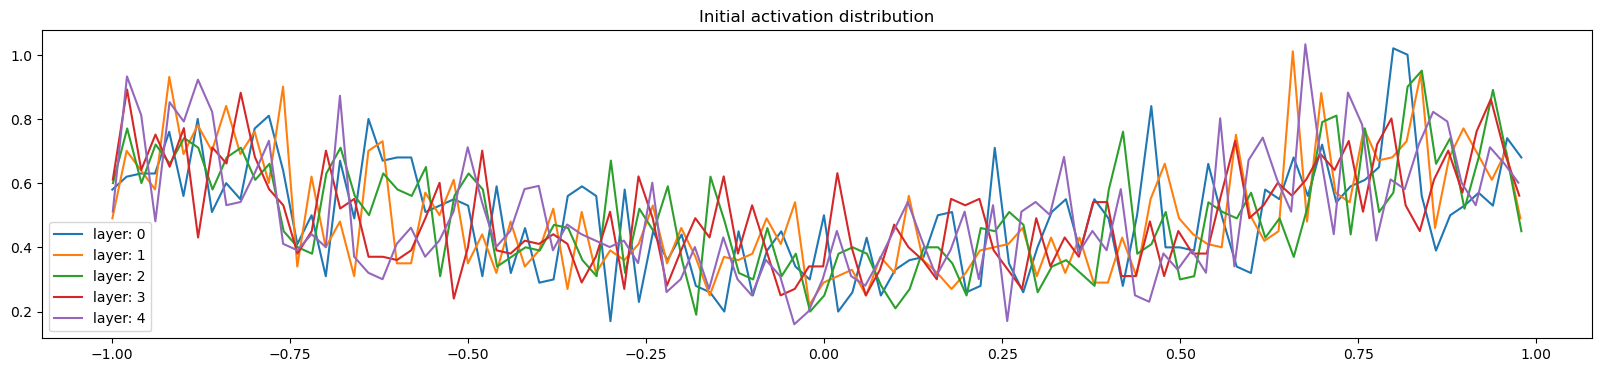

In [196]:
import matplotlib.pyplot as plt

train_words, test_words = split_data(0.9)
train_data = tokenize_data(train_words, block_size=block_size)
test_data = tokenize_data(test_words, block_size=block_size)

mlp = train((train_data, test_data), batch_size=50, lr=1e-1, max_num_epochs=int(2e5), init_debug = True)


# visualize histograms of initial activation distributions
plt.figure(figsize=(20, 4))
legends = []
for i, m in enumerate(mlp.blocks[:-1]):
    t = m.out
    mean = t.mean().item()
    std = t.std().item()
    saturated = (t.abs() > 0.97).float().mean() * 100
    print(f"layer: {i}, mean = {mean:.4f}, std = {std:.4f}, saturated = {saturated:.4f}")
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f"layer: {i}")
plt.legend(legends)
plt.title("Initial activation distribution")
plt.show()
    

## Visualize histograms on initial gradients 

layer: 0, mean = 0.0000, std = 0.00020
layer: 1, mean = -0.0000, std = 0.00018
layer: 2, mean = 0.0000, std = 0.00015
layer: 3, mean = 0.0000, std = 0.00013
layer: 4, mean = 0.0000, std = 0.00011


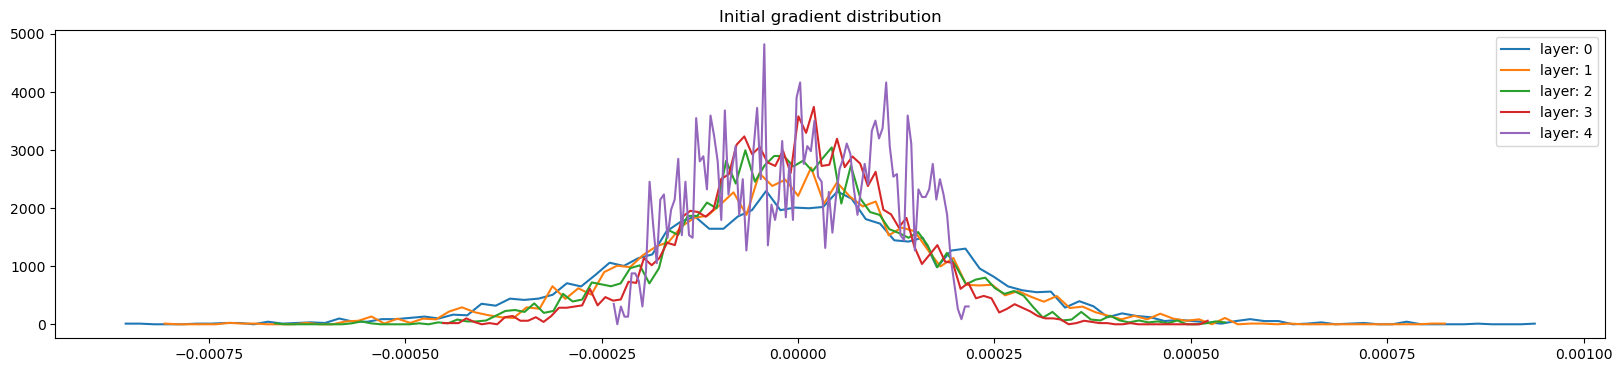

In [197]:
# visualize histograms of initial gradients
plt.figure(figsize=(20, 4))
legends = []
for i, m in enumerate(mlp.blocks[:-1]):
    t = m.out.grad
    mean = t.mean().item()
    std = t.std().item()
    print(f"layer: {i}, mean = {mean:.4f}, std = {std:.5f}")
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f"layer: {i}")
plt.legend(legends)
plt.title("Initial gradient distribution")
plt.show()

## Update to data ratio along epochs

Here we check the standard deviation of the update for each parameter that is: $l_r \Delta \nabla_{\theta_i} \mathcal L$ compared with the standard deviation of the parameter itself, that is: $\Delta \theta_i$. More precisely, we plot 

$$\log_{10}\left( \frac{l_r \Delta \nabla_{\theta_i}\mathcal L}{\Delta\theta_i}\right)$$ 

as a function of the training epoch. The heuristic ratio is $\sim 10^{-3}$

epoch:       0/   3000:----------> loss = 3.3088
epoch:    1000/   3000:----------> loss = 2.6492
epoch:    2000/   3000:----------> loss = 2.2887
3000


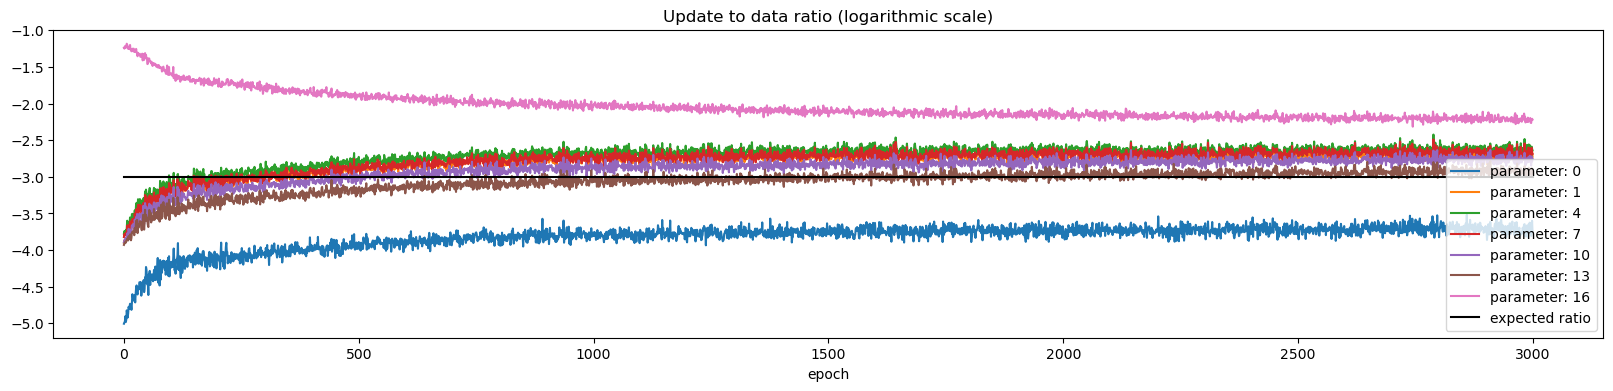

In [202]:
mlp, u2d_ratio = train((train_data, test_data), batch_size=50, lr=2e-2, max_num_epochs=3000, init_debug = False)

print(len(u2d_ratio))

plt.figure(figsize=(20, 4))
legends = []
for j, p in enumerate(mlp.parameters()):
    if p.data.ndim == 2:
        plt.plot([u2d_ratio[i][j] for i in range(len(u2d_ratio))])
        legends.append(f"parameter: {j}")
plt.plot([0, len(u2d_ratio)], [-3.0, -3.0], "k")
legends.append("expected ratio")
plt.legend(legends)
plt.xlabel("epoch")
plt.title("Update to data ratio (logarithmic scale)")
plt.show() 

# Fine tune model architecture

## Process data

In [204]:
import os
import random

@torch.no_grad()
def generate_name_from_model(model: MLP, c_to_i: dict[str, int], i_to_c: dict[int, str], starts_with=None):
    model.eval() 
    block_size = model.block_size 
    if starts_with is None:
        w = []
        x = torch.tensor([[0]*block_size], dtype=torch.long)
    else:
        w = [starts_with]
        x = torch.tensor([[0]*(block_size-1) + [c_to_i[starts_with]]], dtype=torch.long)
    while True:
        logits, _ = model(x)
        P = F.softmax(logits, dim=1)
        next_idx = torch.multinomial(P, num_samples=1, replacement=True).item()
        if next_idx == 0:
            model.train()
            return "".join(w)
        w.append(i_to_c[next_idx])
        x = torch.cat([x[:, 1:], torch.tensor([[next_idx]], dtype=torch.long)], dim=1) 

class DataProcessor:
    def __init__(self, split):
        self.load_data()
        self._get_mappings()
        self.split_data(split)

    def load_data(self):
        with open(os.getcwd() + "/../Data/names.txt", "r") as f:
            self.words = f.read().split("\n")

    def _get_mappings(self):
        chars = sorted(
            list(
                set("".join(self.words))
            ) + ['-']
        )
        self.num_chars = len(chars)
        self.i_to_c = {i: c for i, c in enumerate(chars)}
        self.c_to_i = {c: i for i, c in i_to_c.items()} 

    def split_data(self, split):
        random.shuffle(self.words)
        nt = int(split*len(self.words))
        self.train_words = self.words[:nt]
        self.test_words = self.words[nt:]
            

## Training class 

In [210]:
import torch.optim as optim
from sklearn.utils import gen_batches
from tqdm import tqdm

results_path = os.getcwd() + "/tuner_results/batch_norm"

def save_upload_model_state(model: MLP, trial: int, upload=True, path=None):
    file_path = results_path + (
        f"/model_state_dict_trial_{trial}.pt" if path is None
        else path
    )
    if not upload:
        torch.save(model.state_dict(), file_path)
    else:
        model.load_state_dict(torch.load(file_path, weights_only=True))
        return model         
        

class MLPTrainer:
    def __init__(self, emb_dim, out_dim, block_size, num_blocks, num_epochs, batch_size, data_processor: DataProcessor):
        self.emb_dim = emb_dim
        self.out_dim = out_dim
        self.data_processor = data_processor
        self.train_words = data_processor.train_words.copy() # to avoid modifying train_words attribute in DataProcessor class
        self.block_size = block_size
        self.num_blocks = num_blocks
        self.lr=0.02
        self.num_epochs = num_epochs 
        self.batch_size = batch_size

    def _init_model(self):
        self.model = MLP(emb_dim=self.emb_dim, out_dim=self.out_dim, block_size=self.block_size, num_blocks=self.num_blocks)

    def _init_optimizer(self):
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)

    def split_data(self, split):
        random.shuffle(self.train_words)
        nt = int(split*len(self.train_words))
        Xtr, Ytr = self.tokenize_data(self.train_words[:nt])
        Xval, Yval = self.tokenize_data(self.train_words[nt:])
        return (Xtr, Ytr), (Xval, Yval)
        
    def tokenize_data(self, words):
        X, Y = [], []
        for w in words:
            context = [0]*self.block_size
            for c in w+'-':
                X.append(context)
                Y.append(self.data_processor.c_to_i[c])
                # update context
                context = context[1:] + [self.data_processor.c_to_i[c]]
        return torch.tensor(X, dtype=torch.long), torch.tensor(Y, dtype=torch.long) 
    
    
    def generate_batches(self, data):
        X, Y = data
        train_batches = []
        for s in gen_batches(len(Y), batch_size=self.batch_size):
            train_batches.append((X[s], Y[s]))
        return train_batches 

    def gradient_step(self, x, y):
        self.optimizer.zero_grad()
        _, loss = self.model(x, y=y)
        loss.backward()
        self.optimizer.step()
        return loss.item()  
    
    def run_single_epoch(self, train_batches):
        loss = 0.0
        for x, y in train_batches:
            loss += self.gradient_step(x, y)
        return loss / len(train_batches)

    def run_epochs(self, trial: int):
        losses = []
        self._init_model()
        self._init_optimizer()
        train_data, val_data = self.split_data(split=0.9) 
        train_batches = self.generate_batches(train_data)
        for ep in tqdm(range(self.num_epochs), desc=f"Running epochs for trial {trial}"):
            if ep == int(0.8*self.num_epochs):
                # reduce learning rate for the last 20% of the epochs
                self.optimizer.param_groups[0]["lr"] /= 10   
            losses.append(self.run_single_epoch(train_batches))
        val_loss = self.validate(val_data)
        return val_loss, losses  

    @torch.no_grad()
    def validate(self, val_data):
        self.model.eval()
        x, y = val_data
        _, loss = self.model(x, y=y)
        self.model.train()
        return loss.item()

    @staticmethod
    def visualize(losses):
        plt.plot(range(1, len(losses)+1), losses)
        plt.xlabel("epochs")
        plt.ylabel("entropy loss")
        plt.show() 

## Optuna tuner

In [211]:
import optuna
from dataclasses import dataclass, asdict
import json

@dataclass 
class TunerSettings:
    emb_dim_bounds: tuple[int]
    out_dim_bounds: tuple[int]
    num_epochs: int
    batch_size: int
    num_trials: int

    def dict(self):
        return asdict(self) 


class Tuner:
    def __init__(self, settings: TunerSettings, data_processor: DataProcessor):
        self.settings = settings
        self.data_processor = data_processor
        self.create_study() 

    def create_study(self):
        self.study = optuna.create_study(pruner=optuna.pruners.MedianPruner, direction="minimize")

    def suggest_train_params(self, trial: optuna.trial):
        _ = trial.suggest_int(name="block_size", low=1, high=5)
        _ = trial.suggest_int(name="num_blocks", low=2, high=6)
        _ = trial.suggest_int(name="emb_dim", low=self.settings.emb_dim_bounds[0], high=self.settings.emb_dim_bounds[1])
        _ = trial.suggest_int(name="out_dim", low=self.settings.out_dim_bounds[0], high=self.settings.out_dim_bounds[1])
        return trial.params 
    
    def objective(self, trial: optuna.trial):
        params = self.suggest_train_params(trial)
        params.update(
            {
                "data_processor": self.data_processor,
                "num_epochs": self.settings.num_epochs,
                "batch_size": self.settings.batch_size
            }
        )
        trainer = MLPTrainer(**params)
        try:
            loss, losses = trainer.run_epochs(trial.number)

            with open(results_path + f"/val_train_losses_trial_{trial.number}.json", "w") as f:
                json.dump({"val_loss": loss, "train_loss": losses[-1]}, f)
                
            save_upload_model_state(model=trainer.model, trial=trial.number, upload=False)
        except Exception as exc:
            loss = 1e6
            print(f"\nException {exc} occured during trial {trial.number}")
        return loss
    
    def optimize(self):
        self.study.optimize(self.objective, n_trials=self.settings.num_trials)
        
        print("Best architectural params:\n")
        for name, val in self.study.best_params.items():
            print('#'*4+f" {name} = {val}")
        print(f"\nwith validation loss: {self.study.best_value:.4f}")
        with open(results_path + f"/val_train_losses_trial_{self.study.best_trial.number}.json", "r") as f:
            d = json.load(f)
        print(f"with training loss: {d["train_loss"]:.4f}")
        tuner_results = self.settings.dict()
        tuner_results["best_trial"] = self.study.best_trial.number
        tuner_results.update(self.study.best_params)
        
        with open(results_path + "/tuner_settings_results.json", "w") as f:
            json.dump(tuner_results, f)
        

In [209]:
results_path

'/Users/daviddiegocastro/Desktop/Python code/Language Models/MLP/tuner_results/batch_norm'

### Run tuner

In [212]:
if not os.path.exists(results_path):
    os.makedirs(results_path)


settings = TunerSettings(
    emb_dim_bounds = (2, 10),
    out_dim_bounds = (30, 200),
    num_epochs = 100,
    batch_size = 500,
    num_trials = 20,
)

tuner = Tuner(
    settings=settings,
    data_processor=DataProcessor(split=0.9)  
)

tuner.optimize() 

[I 2026-05-18 21:59:47,527] A new study created in memory with name: no-name-1575320f-b2ed-4b16-97f5-b9da291fa38c
Running epochs for trial 0: 100%|█████████████| 100/100 [01:47<00:00,  1.07s/it]
[I 2026-05-18 22:01:35,162] Trial 0 finished with value: 2.223666191101074 and parameters: {'block_size': 2, 'num_blocks': 3, 'emb_dim': 9, 'out_dim': 112}. Best is trial 0 with value: 2.223666191101074.
Running epochs for trial 1: 100%|█████████████| 100/100 [01:09<00:00,  1.44it/s]
[I 2026-05-18 22:02:44,868] Trial 1 finished with value: 2.112262010574341 and parameters: {'block_size': 5, 'num_blocks': 2, 'emb_dim': 9, 'out_dim': 144}. Best is trial 1 with value: 2.112262010574341.
Running epochs for trial 2: 100%|█████████████| 100/100 [01:23<00:00,  1.20it/s]
[I 2026-05-18 22:04:08,164] Trial 2 finished with value: 2.2266125679016113 and parameters: {'block_size': 2, 'num_blocks': 4, 'emb_dim': 5, 'out_dim': 52}. Best is trial 1 with value: 2.112262010574341.
Running epochs for trial 3: 100

Best architectural params:

#### block_size = 5
#### num_blocks = 4
#### emb_dim = 6
#### out_dim = 78

with validation loss: 2.0594
with training loss: 1.9294


## Generate names from best model

In [213]:
def dummy_model_init(params):
    # instantiate model with appropriate architecture
    return MLP(
        emb_dim=params["emb_dim"],
        out_dim=params["out_dim"],
        block_size=params["block_size"],
        num_blocks=params["num_blocks"],
    )

model = dummy_model_init(tuner.study.best_params)

# upload best model state dictionaty 
model = save_upload_model_state(
    model=model, 
    trial=tuner.study.best_trial.number, 
    upload=True
)

for _ in range(15):
    print(
        generate_name_from_model(
            model=model, 
            c_to_i=tuner.data_processor.c_to_i, 
            i_to_c=tuner.data_processor.i_to_c, 
        )
    )

allion
brockin
porderas
elge
chosa
oluwa
joshits
maroi
mackaileigh
mihani
kelod
matt
carvino
zain
shayden


## Save best model

In [214]:
model = dummy_model_init(tuner.study.best_params)
model = save_upload_model_state(
    model=model, 
    trial=tuner.study.best_trial.number, 
    upload=True
)

if not os.path.exists(results_path+"/best_models"):
    os.makedirs(results_path+"/best_models")
    
save_upload_model_state(
    model=model, 
    trial=None, 
    upload=False,
    path="/best_models/model_state_one_time_lr_reduction.pt"
)

with open(results_path + "/best_models/architecture_one_time_lr_reduction.json", "w") as f:
    json.dump(tuner.study.best_params, f)


## Assess entropy loss of model on test data

In [215]:
def tokenize_data(words, block_size, c_to_i):
        X, Y = [], []
        for w in words:
            context = [0]*block_size
            for c in w+'-':
                X.append(context)
                Y.append(c_to_i[c])
                # update context
                context = context[1:] + [c_to_i[c]]
        return torch.tensor(X, dtype=torch.long), torch.tensor(Y, dtype=torch.long)

Xtest, Ytest = tokenize_data(
    words=tuner.data_processor.test_words,
    block_size=tuner.study.best_params["block_size"],
    c_to_i=tuner.data_processor.c_to_i,
)

def compute_minimum_entropy_loss(X, Y):
    Z = torch.cat([X, Y.view(-1, 1)], dim=-1)
    _, Nxy = torch.unique(Z, return_counts=True, dim=0)
    _, Nx = torch.unique(Z[:,:-1], return_counts=True, dim=0)
    Hxy = (Nxy * torch.log(Nxy)).sum()
    Hx = (Nx * torch.log(Nx)).sum()
    return -(Hxy - Hx) / Nxy.sum()

_, loss = model(Xtest, y=Ytest)

print(f"\nCross-entropy-loss of model over test data: {loss.item():.4f}")

min_loss = compute_minimum_entropy_loss(Xtest, Ytest)

print(f"\nMinimum possible value of cross-entropy loss given test data: {min_loss:.4f}")


Cross-entropy-loss of model over test data: 2.0679

Minimum possible value of cross-entropy loss given test data: 1.1533


---
---